In [1]:
import numpy as np
import pandas as pd
from pysam import VariantFile
import scipy.stats as stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")

import os
import glob
import geopandas as gpd
from sklearn.linear_model import LinearRegression

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def load_tmm_single(tmm_file, batch_file, vcf_file, phenotype_id, variant_id):
    import warnings
    from cyvcf2 import VCF

    if not variant_id:
        warnings.warn(f"Variant {variant_id} does not exist!")

    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    
    # 读取 VCF 中的基因型
    vcf_in = VCF(vcf_file)
    rec = next(vcf_in(f"{chrom}:{position}-{position}"))
    if rec is None:
        raise ValueError(f"Variant {variant_id} not found in VCF.")

    ref, alt = rec.REF, rec.ALT[0]
    sample_names = vcf_in.samples
    genotypes = [sum(gt[:2]) if None not in gt[:2] else np.nan for gt in rec.genotypes]
    genotype_s = pd.Series(genotypes, index=sample_names)

    # 读取表达值
    phenotype_df = pd.read_csv(tmm_file, sep="\t", index_col=3)
    phenotype_df = phenotype_df.iloc[:, 3:]
    phenotype_s = phenotype_df.loc[phenotype_id]

    # 读取协变量矩阵
    batch_df = pd.read_csv(batch_file, sep="\t", index_col=0)
    corrected_phenotype_s = removeBatchEffect(phenotype_s.to_frame(), batch_df.T).iloc[:, 0]

    # 合并数据
    df = pd.DataFrame({
        'phenotype': phenotype_s,
        'genotype': genotype_s
    }).dropna()
    df['genotype'] = df['genotype'].astype(int)
    df['genotype0'] = df['genotype'].replace({
        0: f'{ref}/{ref}',
        1: f'{ref}/{alt}',
        2: f'{alt}/{alt}'
    })

    corrected_df = pd.DataFrame({
        'phenotype': corrected_phenotype_s,
        'genotype': genotype_s
    }).dropna()
    corrected_df['genotype'] = corrected_df['genotype'].astype(int)
    corrected_df['genotype0'] = corrected_df['genotype'].replace({
        0: f'{ref}/{ref}',
        1: f'{ref}/{alt}',
        2: f'{alt}/{alt}'
    })

    return df, corrected_df, ref, alt


In [3]:
import statsmodels.api as sm

def removeBatchEffect(expr, covariates):
    """
    等效于 limma::removeBatchEffect()
    参数:
        expr: 表达矩阵 (样本×基因), DataFrame
        covariates: 协变量矩阵 (样本×PCs), DataFrame
    返回:
        去除批次效应后的矩阵
    """
    # 添加截距项
    X = sm.add_constant(covariates)
    residuals = pd.DataFrame(index=expr.index, columns=expr.columns)
    
    # 对每个基因做线性回归
    for gene in expr.columns:
        y = expr[gene]
        model = sm.OLS(y, X)
        results = model.fit()
        residuals[gene] = results.resid + results.params[0]  # 残差 + 截距
    
    return residuals

In [5]:
def plot_compare_tmm1(df, variant_id, ref, alt, figsize=(3,2.5 ), title=None, ax=None):
    if ax is None:
        sns.set_theme(style="ticks", font_scale=1.1)
        fig, ax = plt.subplots(figsize=figsize)

    # 设置顺序
    genotype_order = [f"{ref}/{ref}", f"{ref}/{alt}", f"{alt}/{alt}"]
    main_color = "#5473AD"

    # stripplot
    sns.stripplot(data=df, x='genotype0', y='phenotype',
                  alpha=0.5, jitter=0.25, ax=ax, color=main_color,
                  order=genotype_order)

    # boxplot
    sns.boxplot(data=df, x='genotype0', y='phenotype',
                width=0.6, linewidth=1.5,
                boxprops=dict(facecolor='none'),  # 空心箱子
                medianprops=dict(color=main_color, linewidth=2),
                whiskerprops=dict(color=main_color),
                capprops=dict(color=main_color),
                flierprops=dict(markerfacecolor='none', markeredgecolor=main_color),
                ax=ax,
                order=genotype_order)

    # 可选：回归线
    sns.regplot(data=df, x='genotype', y='phenotype',
                scatter=False, color='gray', line_kws={'linewidth': 1.5}, ax=ax)

    ax.set_xlabel(variant_id)
    ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
    if title:
        ax.set_title(title)

    sns.despine()
    return ax


In [8]:
def plot_compare_tmm(df, variant_id, ref, alt, figsize=(3, 2.5), title=None, ax=None):
    if ax is None:
        sns.set_theme(style="ticks", font_scale=1.1)
        fig, ax = plt.subplots(figsize=figsize)

    # 设置顺序
    genotype_order = [f"{alt}/{alt}", f"{ref}/{alt}", f"{ref}/{ref}"]
    main_color = "#5473AD"
    genotype_map = {g: i for i, g in enumerate(genotype_order)}
    df['genotype_mapped'] = df['genotype0'].map(genotype_map)
    # stripplot
    sns.stripplot(data=df, x='genotype0', y='phenotype',
                  alpha=0.5, jitter=0.25, ax=ax, color=main_color,
                  order=genotype_order)

    # boxplot
    sns.boxplot(data=df, x='genotype0', y='phenotype',
                width=0.6, linewidth=1.5,
                boxprops=dict(facecolor='none'),  # 空心箱子
                medianprops=dict(color=main_color, linewidth=2),
                whiskerprops=dict(color=main_color),
                capprops=dict(color=main_color),
                flierprops=dict(markerfacecolor='none', markeredgecolor=main_color),
                ax=ax,
                order=genotype_order)

    # 可选：回归线
    sns.regplot(data=df, x='genotype_mapped', y='phenotype',
                scatter=False, color='gray', line_kws={'linewidth': 1.5}, ax=ax)
      
    ax.set_xlabel('')
    ax.set_ylabel(f'Adjusted TMM')
    if title:
        ax.set_title(title)

    sns.despine()
    return ax


# Fig. 9g

C:\Users\Administrator\AppData\Local\Temp\ipykernel_48480\1494288352.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Group'] = df_filtered['Group'].str.extract(r'THNSL2\.([^.]+)\.freq')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48480\1494288352.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Frequency'] = 1 - df_filtered['Frequency']
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48480\1494288352.py:26: SettingWithCopyWarning: 
A value is trying to be set o

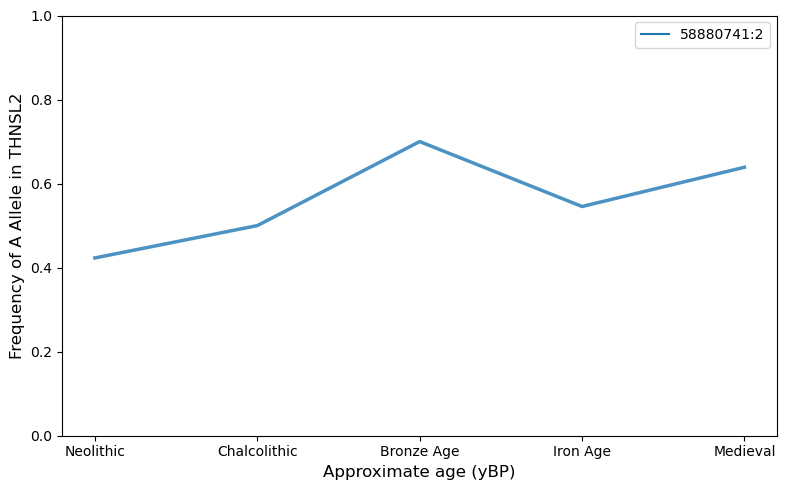

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv('THNSL2.final_merged.tsv', sep="\t")
df['SNP'] = df['CHROM'].astype(str) + ':' + df['POS'].astype(str)
df_long = df.melt(id_vars=['SNP'], var_name='Group', value_name='Frequency')
df_long = df_long[~df_long['Group'].isin(['CHROM', 'POS'])]

# 指定目标 SNP
target_snp = "58880741:2"
df_filtered = df_long[df_long['SNP'] == target_snp]
df_filtered['Group'] = df_filtered['Group'].str.extract(r'THNSL2\.([^.]+)\.freq')
df_filtered['Frequency'] = 1 - df_filtered['Frequency']

# --- 指定 x 轴标签内容的顺序（按你需要的显示方式） ---
group_label_map = {
    'M6': 'Neolithic',
    'M4': 'Chalcolithic',
    'M2': 'Bronze Age',
    'M1':   'Iron Age',
    'M0': 'Medieval'
}

df_filtered['Group'] = df_filtered['Group'].map(group_label_map)

# 按照你提供的顺序设置分类顺序
custom_order = list(group_label_map.values())
df_filtered['Group'] = pd.Categorical(df_filtered['Group'], categories=custom_order, ordered=True)
df_filtered = df_filtered.sort_values('Group')


# 绘图
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_filtered,
    x='Group', 
    y='Frequency',
    hue='SNP',
    linewidth=2.5,
    alpha=0.8
)

# 样式调整
plt.xticks(rotation=0)
plt.xlabel('Approximate age (yBP)', fontsize=12)
plt.ylim(0, 1)
plt.ylabel('Frequency of A Allele in THNSL2', fontsize=12)
plt.legend()  # 移除图例
plt.tight_layout()
#plt.savefig('THNSL2_allele_frequency.2025.6.13.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [6]:
path="/storage/public/home/2021050411/v1.min40_split/"

tissue = 'Skin'
phenotype_id = 'THNSL2'
variant_id = '3_58880741'
#rsid = 'rs402321648'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
tmm_file = f'{path}/{tissue}/phenotypes/{tissue}.tmm.expression.bed.gz'

batch_file = f'{path}/{tissue}/covFile/{tissue}.tsv'

vcf_file = f'{path}/{tissue}/genotypes/{tissue}.vcf.gz'


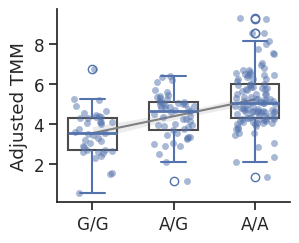

In [9]:
df, corrected_df, ref, alt = load_tmm_single(tmm_file, batch_file, vcf_file, phenotype_id, variant_id)
ax = plot_compare_tmm(corrected_df, variant_id,ref=ref,alt=alt)
plt.savefig(f"{phenotype_id}_{variant_id}.tmm.2025.6.16.pdf", dpi=300, bbox_inches='tight')


# Fig. 9h

C:\Users\Administrator\AppData\Local\Temp\ipykernel_48480\2470955714.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Group'] = df_filtered['Group'].str.extract(r'STK10\.([^.]+)\.freq')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48480\2470955714.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Group'] = df_filtered['Group'].map(group_label_map)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48480\2470955714.py:29: SettingWithCopyWarning: 
A value is trying to 

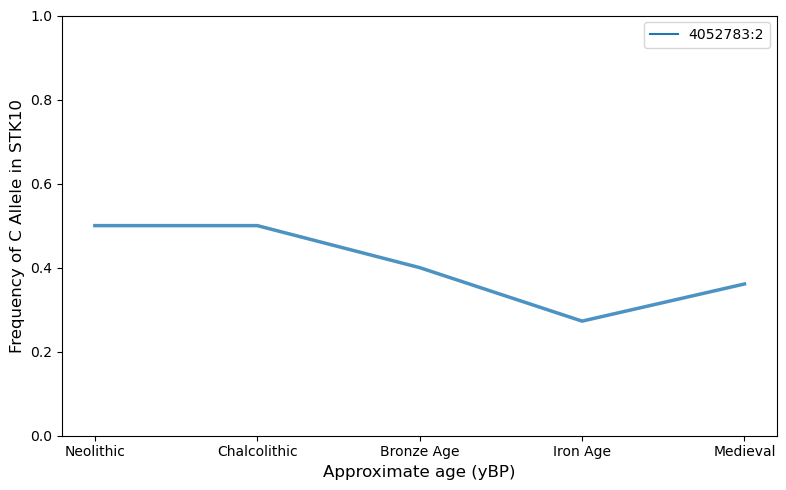

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv("STK10.final_merged.tsv", sep="\t")
df['SNP'] = df['CHROM'].astype(str) + ':' + df['POS'].astype(str)
df_long = df.melt(id_vars=['SNP'], var_name='Group', value_name='Frequency')
df_long = df_long[~df_long['Group'].isin(['CHROM', 'POS'])]

# 指定目标 SNP
target_snp = "4052783:2"
df_filtered = df_long[df_long['SNP'] == target_snp]
df_filtered['Group'] = df_filtered['Group'].str.extract(r'STK10\.([^.]+)\.freq')

# --- 指定 x 轴标签内容的顺序（按你需要的显示方式） ---
group_label_map = {
    'M6': 'Neolithic',
    'M4': 'Chalcolithic',
    'M2': 'Bronze Age',
    'M1':   'Iron Age',
    'M0': 'Medieval'
}

df_filtered['Group'] = df_filtered['Group'].map(group_label_map)

# 按照你提供的顺序设置分类顺序
custom_order = list(group_label_map.values())
df_filtered['Group'] = pd.Categorical(df_filtered['Group'], categories=custom_order, ordered=True)
df_filtered = df_filtered.sort_values('Group')


# 绘图
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_filtered,
    x='Group', 
    y='Frequency',
    hue='SNP',
    linewidth=2.5,
    alpha=0.8
)

# 样式调整
plt.xticks(rotation=0)
plt.xlabel('Approximate age (yBP)', fontsize=12)
plt.ylim(0, 1)
plt.ylabel('Frequency of C Allele in STK10', fontsize=12)
plt.legend()  # 移除图例
plt.tight_layout()
#plt.savefig('STK10_allele_frequency.2025.6.13.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [10]:
path="/storage/public/home/2021050411/v1.min40_split/"

tissue = 'Cervix'
phenotype_id = 'STK10'
variant_id = '16_4052783'
#rsid = 'rs402321648'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
tmm_file = f'{path}/{tissue}/phenotypes/{tissue}.tmm.expression.bed.gz'

batch_file = f'{path}/{tissue}/covFile/{tissue}.tsv'

vcf_file = f'{path}/{tissue}/genotypes/{tissue}.vcf.gz'


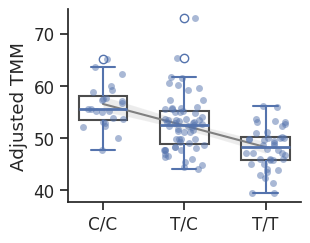

In [12]:
df, corrected_df, ref, alt = load_tmm_single(tmm_file, batch_file, vcf_file, phenotype_id, variant_id)
ax = plot_compare_tmm(corrected_df, variant_id,ref=ref,alt=alt)
plt.savefig(f"{phenotype_id}_{variant_id}.tmm.2025.6.16.pdf", dpi=300, bbox_inches='tight')


# Fig. 9i

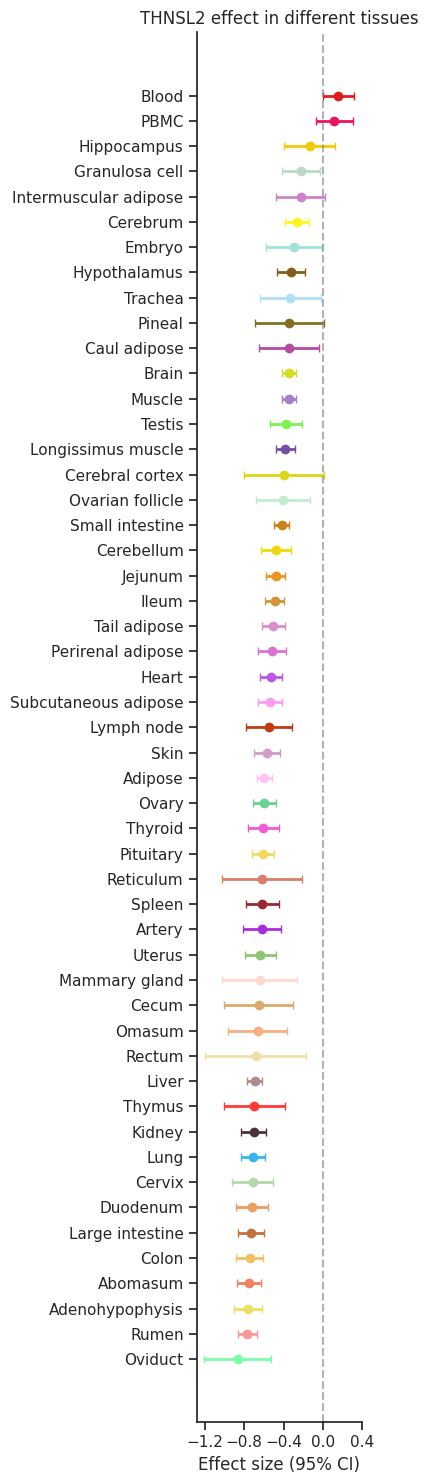

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置组织名字格式
locuszoom_dfv1=pd.read_csv('/storage/public/home/2021050411/20.phase/v3/effect.size/QTL_summary_THNSL2_3_58880741.tsv',sep='\t')

locuszoom_dfv1['Tissue_name'] = locuszoom_dfv1['Tissue'].apply(lambda x: ' '.join(x.split('_')))
# columns: Tissue_name, Color
color_df = pd.read_csv('/storage/public/home/2021050411/v1.min40_split/tissue.color', sep='\t')  # 或者 Excel，根据实际情况

# 将颜色合并进主数据框
locuszoom_dfv1 = locuszoom_dfv1.merge(color_df, on='Tissue_name', how='left')

# 按 effect size 排序（可选）
locuszoom_dfv1 = locuszoom_dfv1.sort_values(by='slope', ascending=True)

# 画图
sns.set_theme(style="ticks")
plt.figure(figsize=(4, 15))  # 根据组织数自动调整图高

ax = plt.gca()

# 遍历每一行，单独绘制 errorbar
for _, row in locuszoom_dfv1.iterrows():
    ax.errorbar(
        x=row['slope'],
        y=row['Tissue_name'],
        xerr=[[row['slope'] - row['ci_lower']], [row['ci_upper'] - row['slope']]],
        fmt='o',
        color=row['Color'],         # 点的颜色
        ecolor=row['Color'],        # 误差线颜色
        elinewidth=2,
        capsize=3,
        alpha=1
    )


ax.axvline(0, color='grey', linestyle='--', alpha=0.6)
ax.set_xlabel('Effect size (95% CI)')
ax.set_xticks([-1.2,-0.8,-0.4,0,0.4])
ax.set_ylabel('')
ax.set_title('THNSL2 effect in different tissues')
sns.despine()

# 保存图
output_pdf = 'THNSL2_3_58880741_effect_size_forestplot.2025.6.13.pdf'
plt.tight_layout()
plt.savefig(output_pdf)
#print(f"✅ 图像已保存：{output_pdf}")
plt.show()


# Fig. 9j

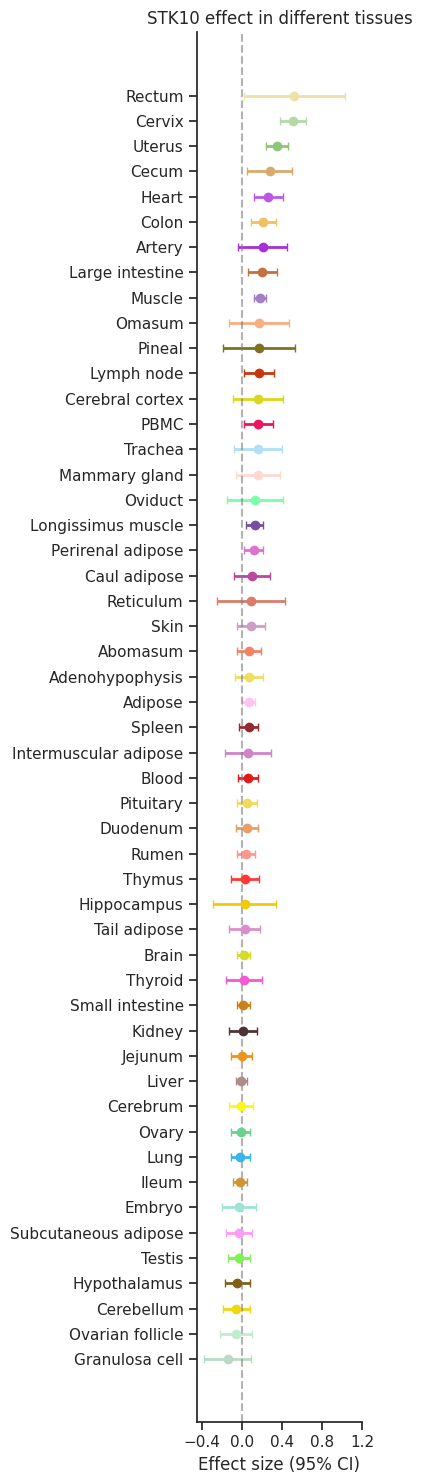

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置组织名字格式
locuszoom_dfv1=pd.read_csv('/storage/public/home/2021050411/20.phase/v3/effect.size/QTL_summary_STK10_16_4052783.tsv',sep='\t')

locuszoom_dfv1['Tissue_name'] = locuszoom_dfv1['Tissue'].apply(lambda x: ' '.join(x.split('_')))
# columns: Tissue_name, Color
color_df = pd.read_csv('/storage/public/home/2021050411/v1.min40_split/tissue.color', sep='\t')  # 或者 Excel，根据实际情况

# 将颜色合并进主数据框
locuszoom_dfv1 = locuszoom_dfv1.merge(color_df, on='Tissue_name', how='left')

# 按 effect size 排序（可选）
locuszoom_dfv1 = locuszoom_dfv1.sort_values(by='slope', ascending=True)

# 画图
sns.set_theme(style="ticks")
plt.figure(figsize=(4, 15))  # 根据组织数自动调整图高

ax = plt.gca()

# 遍历每一行，单独绘制 errorbar
for _, row in locuszoom_dfv1.iterrows():
    ax.errorbar(
        x=row['slope'],
        y=row['Tissue_name'],
        xerr=[[row['slope'] - row['ci_lower']], [row['ci_upper'] - row['slope']]],
        fmt='o',
        color=row['Color'],         # 点的颜色
        ecolor=row['Color'],        # 误差线颜色
        elinewidth=2,
        capsize=3,
        alpha=1
    )


ax.axvline(0, color='grey', linestyle='--', alpha=0.6)
ax.set_xlabel('Effect size (95% CI)')
ax.set_xticks([-0.4,0,0.4,0.8,1.2])
ax.set_ylabel('')
ax.set_title('STK10 effect in different tissues')
sns.despine()

# 保存图
output_pdf = 'STK10_16_4052783_effect_size_forestplot.2025.6.13.pdf'
plt.tight_layout()
#plt.savefig(output_pdf)
#print(f"✅ 图像已保存：{output_pdf}")
plt.show()
